# Project 4: Predicting a Continuous Target with Regression 

- Author: Kim Hummel
- Date: 2026-07
- Dataset: Seaborn; Titanic
- Target: Fare

In this project we will follow the outline provided by Denise Case on the Titanic data set from seaborn. We’ll predict fare, the amount of money paid for the journey, using age, family size, and embarked town.  

## Section 0: Project Set Up & Imports

In [104]:
# === Section 0a: Declare Imports ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# === Section 0b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04", level="DEBUG")
log_header(LOG, "M04")

# === Section 0c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 0d. SET PANDAS DISPLAY CONFIGURATION  ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-26 20:02:59 | INFO | M04 | === RUN START ===
2026-07-26 20:02:59 | INFO | M04 | project=M04
2026-07-26 20:02:59 | INFO | M04 | repo_dir=ml-04-regression
2026-07-26 20:02:59 | INFO | M04 | python=3.14.3
2026-07-26 20:02:59 | INFO | M04 | os=Windows 11
2026-07-26 20:02:59 | INFO | M04 | shell=powershell
2026-07-26 20:02:59 | INFO | M04 | cwd=notebooks\04 Project
2026-07-26 20:02:59 | INFO | M04 | github_actions=False
2026-07-26 20:02:59 | INFO | M04 | Confirming installation:
2026-07-26 20:02:59 | INFO | M04 |   python:       3.14.3
2026-07-26 20:02:59 | INFO | M04 |   pandas:       3.0.3
2026-07-26 20:02:59 | INFO | M04 |   numpy:        2.5.1
2026-07-26 20:02:59 | INFO | M04 |   scikit-learn: 1.9.0
2026-07-26 20:02:59 | INFO | M04 |   seaborn:      0.13.2
2026-07-26 20:02:59 | INFO | M04 |   matplotlib:   3.11.1


## Section 1: Import and Inspect Data

We start with importing the data and then taking a look at it to know how to analyze it. 

In [105]:
# Load Titanic dataset from seaborn and verify
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [106]:
numeric_cols_list: list[str] = titanic.select_dtypes(include="number").columns.tolist()
category_cols_list: list[str] = titanic.select_dtypes(exclude="number").columns.tolist()

LOG.info(f"Numeric columns (regression target / numeric feature): {numeric_cols_list}")
LOG.info(
    f"Categorical columns (classification target / category): {category_cols_list}"
)

missing: pd.Series = titanic.isna().sum()
LOG.info(f"Missing values by column:\n{missing}")

2026-07-26 20:02:59 | INFO | M04 | Numeric columns (regression target / numeric feature): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
2026-07-26 20:02:59 | INFO | M04 | Categorical columns (classification target / category): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
2026-07-26 20:02:59 | INFO | M04 | Missing values by column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Section 2. Data Exploration and Preparation
Prepare data for the regression model 

In [107]:
# find median age
titanic['age'].median()

np.float64(28.0)

In [108]:
# find most popular city to embark from
titanic['embarked'].mode()

0    S
Name: embarked, dtype: str

In [109]:
# fill in missing age values with median age
titanic['age'] = titanic['age'].fillna(28)
LOG.info('Missing ages were filled with the median age, 28')
LOG.info(f'Number of missing values in column:{titanic['embarked'].isnull().sum()}')
LOG.info("========================")

# Drop any row with missing fare data
titanic = titanic.dropna(subset=['fare'])
LOG.info('All rows with no fare were dropped from the dataframe')
LOG.info(f'Number of missing values in column:{titanic['fare'].isnull().sum()}')
LOG.info("========================")

# fill in missing embarked with most popular city
titanic['embarked'] = titanic['embarked'].fillna('S')
LOG.info('Missing values for embarked were filled in with the mode, S')
LOG.info(f'Number of missing values in column:{titanic['embarked'].isnull().sum()}')
LOG.info("========================")

# Calculate family size
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
LOG.info('Family Size Calculated')
LOG.info("========================")

# Changing embarked and sex to numbers
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})
LOG.info('Features sex and embarked changed to numerical values')
LOG.info("========================")

2026-07-26 20:03:00 | INFO | M04 | Missing ages were filled with the median age, 28
2026-07-26 20:03:00 | INFO | M04 | Number of missing values in column:2
2026-07-26 20:03:00 | INFO | M04 | ========================
2026-07-26 20:03:00 | INFO | M04 | All rows with no fare were dropped from the dataframe
2026-07-26 20:03:00 | INFO | M04 | Number of missing values in column:0
2026-07-26 20:03:00 | INFO | M04 | ========================
2026-07-26 20:03:00 | INFO | M04 | Missing values for embarked were filled in with the mode, S
2026-07-26 20:03:00 | INFO | M04 | Number of missing values in column:0
2026-07-26 20:03:00 | INFO | M04 | ========================
2026-07-26 20:03:00 | INFO | M04 | Family Size Calculated
2026-07-26 20:03:00 | INFO | M04 | ========================
2026-07-26 20:03:00 | INFO | M04 | Features sex and embarked changed to numerical values
2026-07-26 20:03:00 | INFO | M04 | ========================


## Section 3. Feature Selection and Justification

We create 4 separate cases to test their ability to predict fare. 

In [110]:
# Case 1. age
X1 = titanic[['age']]
y1 = titanic['fare']

# Case 2. family_size
X2 = titanic[['family_size']]
y2 = titanic['fare']

# Case 3. age, family_size
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

# Case 4. embarked
X4 = titanic[['embarked']]
y4 = titanic['fare']

# Case 5. pclass
X5 = titanic[['pclass']]
y5 = titanic['fare']

# Case 6. pclass, embarked
X6 = titanic[['pclass', 'embarked']]
y6 = titanic['fare']

## Section 3 Reflection Questions

1) Why might these features affect a passenger’s fare? - Age could affect ticket price as sometimes children's tickets are cheaper or discounts are given for senior citizens. Family size could impact ticket price if a a reduction is given if you purchase multiple tickets. And the town you leave from could affect the price of your ticket as if you left from a closer town your time on the Titanic would be less, and therefore your price would be cheaper. 
2) List all available features: survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone
3) Which other features could improve predictions and why? - pclass. I just realized that what class of ticket you bought will definitely affect your price. I might add that on as a separate case from what I originally planned. 
4) How many variables are in your Case 4? - One; embarked. Although I added on two extra classes. Class 5 has one variable, pclass. Class 6 has two variables, embarked and pclass. 
5) Which variable(s) did you choose for Case 4 and why do you feel those could make good inputs? I feel like embarked is a good choice because which port you leave from determines your time on the Titanic, and that can determine your fare price. It currently does for a plain or train ticket current day. The class of ticket should also predict the fare amount fairly well as which class of ticket you bought determined how much space you had on the ship and the access you had to which parts of the boat. These are things that determine the ticket price on current day cruise ships so it would be reasonable to guess they had an impact on the price as well. 

## Section 4. Train a Regression Model (Linear Regression)

In [111]:
# 4.1 Split the Data

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=123
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=123
)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=123
)

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=123
)

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=123
)

X6_train, X6_test, y6_train, y6_test = train_test_split(
    X6, y6, test_size=0.2, random_state=123
)

In [112]:
# 4.2 Train and Evaluate Linear Regression Models (all 6 cases)

lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)
lr_model5 = LinearRegression().fit(X5_train, y5_train)
lr_model6 = LinearRegression().fit(X6_train, y6_train)

# Predictions

y_pred_train1 = lr_model1.predict(X1_train)
y_pred_test1 = lr_model1.predict(X1_test)

y_pred_train2 = lr_model2.predict(X2_train)
y_pred_test2 = lr_model2.predict(X2_test)

y_pred_train3 = lr_model3.predict(X3_train)
y_pred_test3 = lr_model3.predict(X3_test)

y_pred_train4 = lr_model4.predict(X4_train)
y_pred_test4 = lr_model4.predict(X4_test)

y_pred_train5 = lr_model5.predict(X5_train)
y_pred_test5 = lr_model5.predict(X5_test)

y_pred_train6 = lr_model6.predict(X6_train)
y_pred_test6 = lr_model6.predict(X6_test)

In [113]:
# 4.3 Report Performance

print("Case 1: Training R²:", r2_score(y1_train, y_pred_train1))
print("Case 1: Test R²:", r2_score(y1_test, y_pred_test1))
print("Case 1: Test RMSE:", root_mean_squared_error(y1_test, y_pred_test1))
print("Case 1: Test MAE:", mean_absolute_error(y1_test, y_pred_test1))
print("========================")

print("Case 2: Training R²:", r2_score(y2_train, y_pred_train2))
print("Case 2: Test R²:", r2_score(y2_test, y_pred_test2))
print("Case 2: Test RMSE:", root_mean_squared_error(y2_test, y_pred_test2))
print("Case 2: Test MAE:", mean_absolute_error(y2_test, y_pred_test2))
print("========================")

print("Case 3: Training R²:", r2_score(y3_train, y_pred_train3))
print("Case 3: Test R²:", r2_score(y2_test, y_pred_test3))
print("Case 3: Test RMSE:", root_mean_squared_error(y3_test, y_pred_test3))
print("Case 3: Test MAE:", mean_absolute_error(y3_test, y_pred_test3))
print("========================")

print("Case 4: Training R²:", r2_score(y4_train, y_pred_train4))
print("Case 4: Test R²:", r2_score(y4_test, y_pred_test4))
print("Case 4: Test RMSE:", root_mean_squared_error(y4_test, y_pred_test4))
print("Case 4: Test MAE:", mean_absolute_error(y4_test, y_pred_test4))
print("========================")

print("Case 5: Training R²:", r2_score(y5_train, y_pred_train5))
print("Case 5: Test R²:", r2_score(y5_test, y_pred_test5))
print("Case 5: Test RMSE:", root_mean_squared_error(y5_test, y_pred_test5))
print("Case 5: Test MAE:", mean_absolute_error(y5_test, y_pred_test5))
print("========================")

print("Case 6: Training R²:", r2_score(y6_train, y_pred_train6))
print("Case 6: Test R²:", r2_score(y6_test, y_pred_test6))
print("Case 6: Test RMSE:", root_mean_squared_error(y6_test, y_pred_test6))
print("Case 6: Test MAE:", mean_absolute_error(y6_test, y_pred_test6))
print("========================")

Case 1: Training R²: 0.009950688019452314
Case 1: Test R²: 0.0034163395508415295
Case 1: Test RMSE: 37.97164180172938
Case 1: Test MAE: 25.28637293162364
Case 2: Training R²: 0.049915792364760736
Case 2: Test R²: 0.022231186110131973
Case 2: Test RMSE: 37.6114940041967
Case 2: Test MAE: 25.02534815941641
Case 3: Training R²: 0.07347466201590014
Case 3: Test R²: 0.049784832763073106
Case 3: Test RMSE: 37.0777586646559
Case 3: Test MAE: 24.284935030470688
Case 4: Training R²: 0.05013103388476037
Case 4: Test R²: 0.05075533749576355
Case 4: Test RMSE: 37.05881909479762
Case 4: Test MAE: 24.569498388764035
Case 5: Training R²: 0.3005588037487471
Case 5: Test R²: 0.3016017234169923
Case 5: Test RMSE: 31.7873316928033
Case 5: Test MAE: 20.653703671484056
Case 6: Training R²: 0.3182447277079269
Case 6: Test R²: 0.3295273925136103
Case 6: Test RMSE: 31.145335522285475
Case 6: Test MAE: 21.315443001585543


## Section 4 Reflection Questions

### Compare the train vs test results for each.

1) Did Case 1 overfit or underfit? Explain: Case 1 underfit the data. We know this because both R^2, or correlation of determination, are low and close to each other. This means either the model did not understand the data and is not a good model, or there is no correlation between the data. 

2) Did Case 2 overfit or underfit? Explain: Case 2 underfit the data. We know this because both R^2, or correlation of determination, are low and close to each other. This means either the model did not understand the data and is not a good model, or there is no correlation between the data. 

3) Did Case 3 overfit or underfit? Explain: Case 3 underfit the data. We know this because both R^2, or correlation of determination, are low and close to each other. This means either the model did not understand the data and is not a good model, or there is no correlation between the data. 

4) Did Case 4 overfit or underfit? Explain: Case 4 underfit the data. We know this because both R^2, or correlation of determination, are low and close to each other. This means either the model did not understand the data and is not a good model, or there is no correlation between the data. 

5) Did Case 5 overfit or underfit? Explain: Case 5 neither underfit nor overfit the data. The R^2 values are close together, so there is a similarity between the training and testing data (meaning they are not overfitting), and those values are not as low as the previous 4 cases (meaning they are not underfitting). 

6) Did Case 6 overfit or underfit? Explain: Case 6 neither underfit nor overfit the data. The R^2 values are close together, so there is a similarity between the training and testing data (meaning they are not overfitting), and those values are not as low as the previous 4 cases (meaning they are not underfitting). 

### Adding Age

7) Did adding age improve the model: It did improve the model but not significantly. 
8) Propose a possible explanation (consider how age might affect ticket price, and whether the data supports that): One possible explanation is that it doesn't matter a person's age, they will take up the same amount of space in terms of lodging and existing on the ship. If a person is 5 years old, 45 years old, or 85 years old, they will need a bed to sleep in and a spot at a table to eat. Usually when discounts are given because of age it is because they are using less of the service. But on a cruise ship, the space they need on the ship for their basic needs to be met is the same. 

### Worst

9) Which case performed the worst: age performed the worst on its own. 
10) How do you know: Both R^2 values were less than 0.01. 
11) Do you think adding more training data would improve it (and why/why not): No, I do not think that adding more training data would improve it. Either there is no correlation or the model is bad, meaning adding in more data wouldn't help fix those problems. It is also a part of the definition of underfitting data that adding more data instances will not improve the model. 

### Best

12) Which case performed the best: Case 6
13) How do you know: It had the highest R^2 values and they were within 0.011 of each other. It also had the second lowest RMSE and MAE. 
14) Do you think adding more training data would improve it (and why/why not): Yes, adding more training data would improve it so that it could hone into any of the patterns that are happening better. 

## Section 5. Compare Alternative Models
Explore other regression models with Case 6; pclass and embarked

### 5.1 Ridge Regression (L2 penalty)

In [114]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X6_train, y6_train)
y_pred_ridge = ridge_model.predict(X6_test)

### 5.2 Elastic Net (L1 + L2 combined)

In [115]:
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic_model.fit(X6_train, y6_train)
y_pred_elastic = elastic_model.predict(X6_test)

### 5.3 Polynomial Regression

In [116]:
# Set up the poly inputs
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X5_train)
X_test_poly = poly.transform(X5_test)

In [117]:
# Use the poly inputs in the LR model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y5_train)
y_pred_poly = poly_model.predict(X_test_poly)

### 5.4 Visualize Polynomial Cubic Fit (for 1 input feature)
Case 5: pclass only

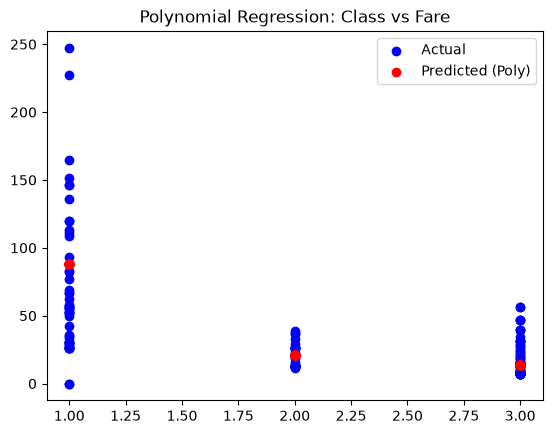

In [118]:
plt.scatter(X5_test, y5_test, color='blue', label='Actual')
plt.scatter(X5_test, y_pred_poly, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression: Class vs Fare")
plt.show()

### 5.4 Reflections

What patterns does the cubic model seem to capture? - It captures that the predicted values do land in the range of actual values. It also shows the downward trend of a cheaper ticket the lower the class. 

Where does it perform well or poorly? - It performs well in giving a distinction between the three classes, but there is a fairly large spread of ticket price in each class that is not captured by the red polynomial dots. 

Did the polynomial fit outperform linear regression? Based on the graph, it did not outperform it. It just performed similarly to it. 

Where (on the graph or among which kinds of data points) does it fit best? It fits best with the lower data points of each class. 


In [119]:
def report(name, y_true, y_pred):
    print(f"{name} R²: {r2_score(y_true, y_pred):.3f}")
    print(f"{name} RMSE: {root_mean_squared_error(y_true, y_pred):.2f}")
    print(f"{name} MAE: {mean_absolute_error(y_true, y_pred):.2f}\n")
    print("========================")


report("Linear", y6_test, y_pred_test6)
report("Ridge", y6_test, y_pred_ridge)
report("ElasticNet", y6_test, y_pred_elastic)
report("Polynomial", y5_test, y_pred_poly)

Linear R²: 0.330
Linear RMSE: 31.15
Linear MAE: 21.32

Ridge R²: 0.330
Ridge RMSE: 31.13
Ridge MAE: 21.29

ElasticNet R²: 0.366
ElasticNet RMSE: 30.29
ElasticNet MAE: 19.83

Polynomial R²: 0.336
Polynomial RMSE: 30.99
Polynomial MAE: 19.25



### 5.5 Visualize Higher Order Polynomial
Case 5: pclass

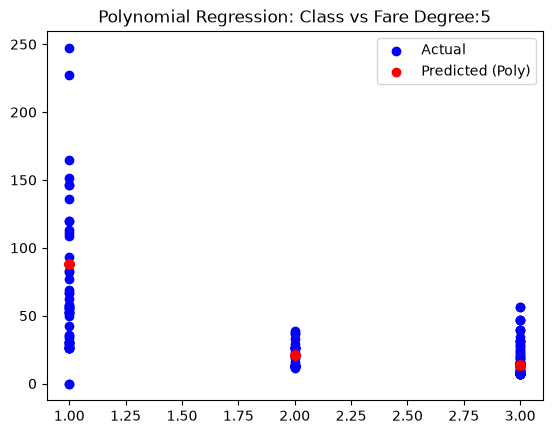

Polynomial R²: 0.336
Polynomial RMSE: 30.99
Polynomial MAE: 19.25



In [120]:
# Set up the poly inputs
poly = PolynomialFeatures(degree=5)
X_train_poly5 = poly.fit_transform(X5_train)
X_test_poly5 = poly.transform(X5_test)

# Use the poly inputs in the LR model
poly_model5 = LinearRegression()
poly_model5.fit(X_train_poly5, y5_train)
y_pred_poly5 = poly_model5.predict(X_test_poly5)

plt.scatter(X5_test, y5_test, color='blue', label='Actual')
plt.scatter(X5_test, y_pred_poly5, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression: Class vs Fare Degree:5")
plt.show()

report("Polynomial", y5_test, y_pred_poly5)

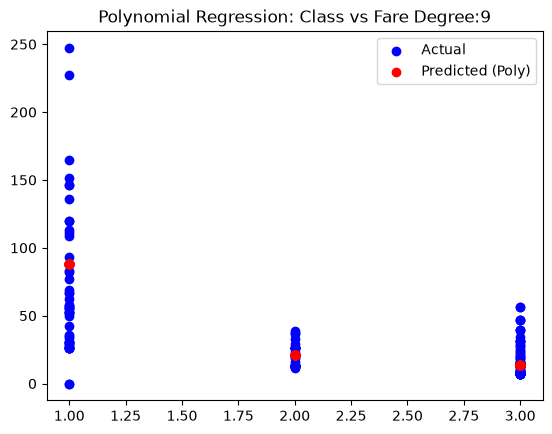

Polynomial R²: 0.336
Polynomial RMSE: 30.99
Polynomial MAE: 19.25



In [121]:
# Set up the poly inputs
poly = PolynomialFeatures(degree=9)
X_train_poly9 = poly.fit_transform(X5_train)
X_test_poly9 = poly.transform(X5_test)

# Use the poly inputs in the LR model
poly_model9 = LinearRegression()
poly_model9.fit(X_train_poly9, y5_train)
y_pred_poly9 = poly_model9.predict(X_test_poly9)

plt.scatter(X5_test, y5_test, color='blue', label='Actual')
plt.scatter(X5_test, y_pred_poly9, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression: Class vs Fare Degree:9")
plt.show()

report("Polynomial", y5_test, y_pred_poly9)

### 5.5 Best Polynomial

I tested two more polynomials, one with a degree of 5 and the other with a degree of 9. The output was exactly the same for all three cases. 

In this case, I would stick with a degree of 3, because I am getting the same output I would stick with the simplest formula to make the model less complicated. 

## Section 6. Final Thoughts & Insights

### 6.1 Summarize Findings

What features were most useful? - Pclass was by far the most useful feature. Adding the embarked town did increase the R-squared scores a little bit, but the main predictive feature was the class of ticket bought. 

What regression model performed best? - The elastic model performed the best. It had the highest R-squared value, the lowest MAE, and the second lowest RMSE (by 0.7) off all of the models. 

How did model complexity or regularization affect results? - It affected the results by slightly increasing the ability of the model. R-squared only increased by 0.006. RMSE only decreased by 0.86. And MAE only decreased by 2.07

### 6.2 Discuss Challenges

Was fare hard to predict? Why? - If I had just stayed with my original option, the fare would have been extreamly hard to predict. When I realized that I should have picked pclass instead of embarked town I added on a case 5 and 6 to explore more. Even with finding pclass which had R-squared values above 0.10 (unlike all of the other cases), it still only had an R-squared value of under 0.33, which is closer to zero than it is to one. So overall, yes, fare is hard to predict. 

Did skew or outliers impact the models? - There were some very high priced first class tickets that most likely skewed the data set as they were outliers from the rest of the ticket prices. 

### 6.3 Optional Next Steps

Try different features besides the ones used (e.g., pclass, sex if you didn't use them this time) - I accidentally did this one from the beginning. I created a case 5 and 6 because I wanted to take a look at pclass, and pclass along with embarked as well. 